In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from glob import glob

import os
import cv2
import gc
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [16]:
# Dataset path (replace with your folder path)
data_path = '/content/drive/MyDrive/AneN_Dasaset'

# Two classes: Anemic and Normal
classes = ["Anemic_individuals", "Healthy_individuals"]

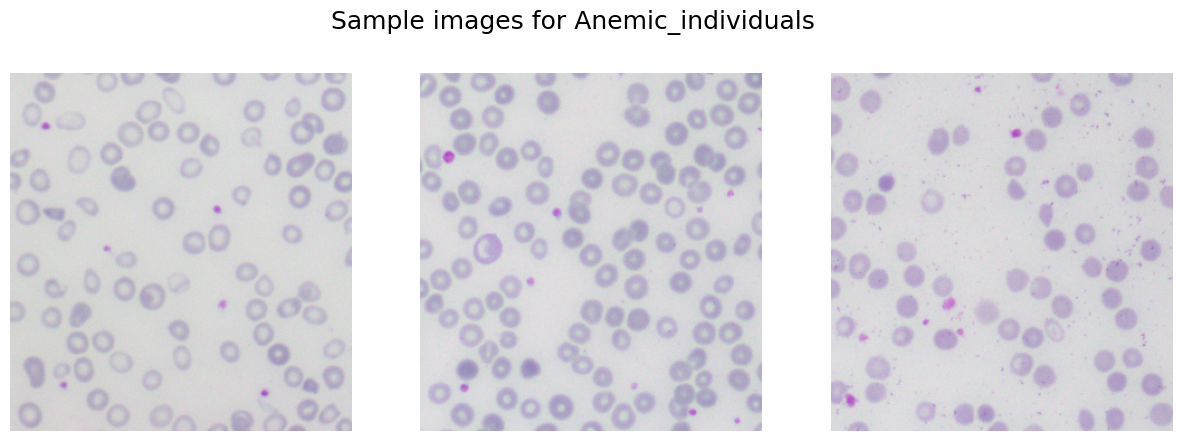

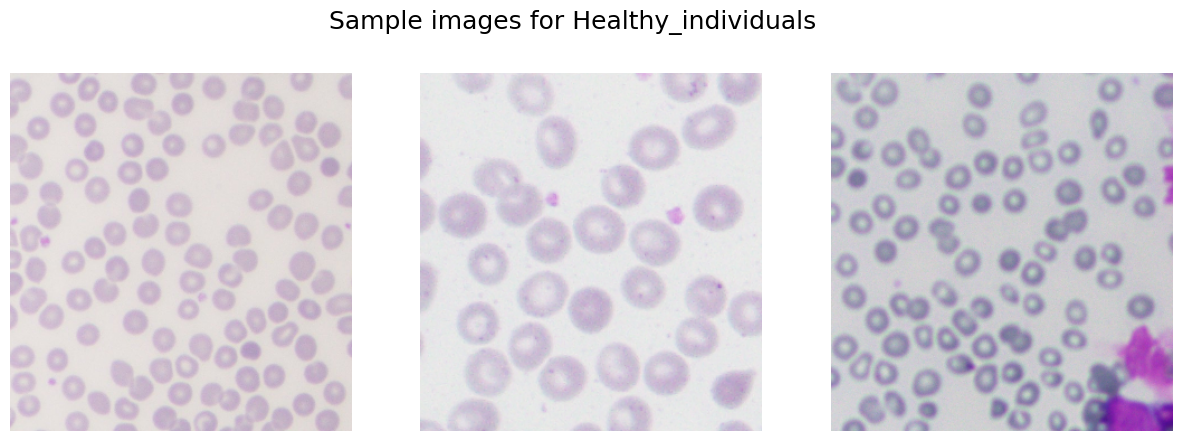

In [17]:
for cat in classes:
    image_dir = f'{data_path}/{cat}'
    images = os.listdir(image_dir)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Sample images for {cat}', fontsize=18)

    for i in range(3):
        k = np.random.randint(0, len(images))
        img = np.array(Image.open(f'{image_dir}/{images[k]}'))
        ax[i].imshow(img)
        ax[i].axis('off')
    plt.show()

In [18]:
print("Dataset path exists:", os.path.exists(data_path))
print("Folders:", os.listdir(data_path))

Dataset path exists: True
Folders: ['Healthy_individuals', 'Anemic_individuals']


In [19]:
from glob import glob
import numpy as np
from sklearn.model_selection import train_test_split
import os
import cv2 # Make sure cv2 is imported

# Dataset path (replace with your folder path)
data_path = '/content/drive/MyDrive/AneN_Dasaset'

# Two classes: Anemic and Normal
classes = ["Anemic_individuals", "Healthy_individuals"]

IMG_SIZE = 256
SAMPLES_PER_CLASS = 1000
SPLIT = 0.2  # 20% validation

X = []
Y = []

for i, cat in enumerate(classes):
    extensions = ['*.jpeg', '*.jpg', '*.png']
    images_list = []

    # Construct the full path to the category directory
    category_path = f'{data_path}/{cat}'

    # Check if the directory exists
    if not os.path.exists(category_path):
        print(f"Error: Directory not found at {category_path}. Please check your dataset path and folder structure.")
        continue # Skip to the next category if directory doesn't exist

    # Print directory content for debugging
    print(f"Content of {category_path}: {os.listdir(category_path)[:5]}...") # print first 5 items

    for ext in extensions:
        images_list.extend(glob(f'{category_path}/{ext}'))

    # Limit to 1000 samples per class
    images_list = images_list[:SAMPLES_PER_CLASS]
    print(f"{cat}: {len(images_list)} images loaded")

    for img_path in images_list:
        img = cv2.imread(img_path)
        if img is None: # Add check for cv2.imread failing
            print(f"Warning: Could not read image {img_path}. Skipping.")
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # BGR to RGB
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        X.append(img)
        Y.append(i)

# Convert to numpy arrays
if not X: # Check if X is empty before converting
    print("No images were loaded. Cannot perform train-validation split.")
else:
    X = np.array(X) / 255.0  # Normalize pixels
    Y = np.array(Y)

    # Train-validation split
    X_train, X_val, Y_train, Y_val = train_test_split(
        X, Y, test_size=SPLIT, random_state=42, stratify=Y
    )
    print(f"Dataset loaded: {len(X_train)} training images, {len(X_val)} validation images.")

Content of /content/drive/MyDrive/AneN_Dasaset/Anemic_individuals: ['010_a.png', '011_a.png', '009_a.png', '012_a.png', '042_a.png']...
Anemic_individuals: 1000 images loaded
Content of /content/drive/MyDrive/AneN_Dasaset/Healthy_individuals: ['010_h.png', '011_h.png', '009_h.png', '012_h.png', '008_h.png']...
Healthy_individuals: 1000 images loaded
Dataset loaded: 1600 training images, 400 validation images.


In [20]:
from tensorflow import keras
from keras import layers

model = keras.models.Sequential([
    layers.Conv2D(32, (5,5), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.BatchNormalization(),
    layers.Dense(2, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 256, 256, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    16,777,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,872,898 (64.36 MB)

 Trainable params: 16,872,642 (64.36 MB)

 Non-trainable params: 256 (1.00 KB)

In [21]:
import tensorflow as tf
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Stop training if val_accuracy > 90%
class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if logs.get('val_accuracy') > 0.90:
            print("\nValidation accuracy > 90%, stopping training.")
            self.model.stop_training = True

es = EarlyStopping(patience=3, monitor='val_accuracy', restore_best_weights=True)
lr = ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, verbose=1)

In [22]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
BATCH_SIZE = 32
EPOCHS = 15

# One-hot encode labels
Y_train_one_hot = tf.keras.utils.to_categorical(Y_train, num_classes=2)
Y_val_one_hot = tf.keras.utils.to_categorical(Y_val, num_classes=2)

history = model.fit(
    X_train, Y_train_one_hot,
    validation_data=(X_val, Y_val_one_hot),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[es, lr],
    verbose=1
)

Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 177ms/step - accuracy: 0.4992 - loss: 0.8054 - val_accuracy: 0.5025 - val_loss: 0.6835 - learning_rate: 1.0000e-04
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - accuracy: 0.5341 - loss: 0.7331 - val_accuracy: 0.5000 - val_loss: 0.9480 - learning_rate: 1.0000e-04
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - accuracy: 0.5309 - loss: 0.7029 - val_accuracy: 0.5975 - val_loss: 0.6806 - learning_rate: 1.0000e-04
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.5717 - loss: 0.6808 - val_accuracy: 0.5000 - val_loss: 4.2603 - learning_rate: 1.0000e-04
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.5228 - loss: 0.7503
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - accuracy: 0.5225 - loss: 0.7504 - val_accuracy: 0.5000 - val_loss: 0.8303 - learning_rate: 1.0000e-04
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.5323 - l

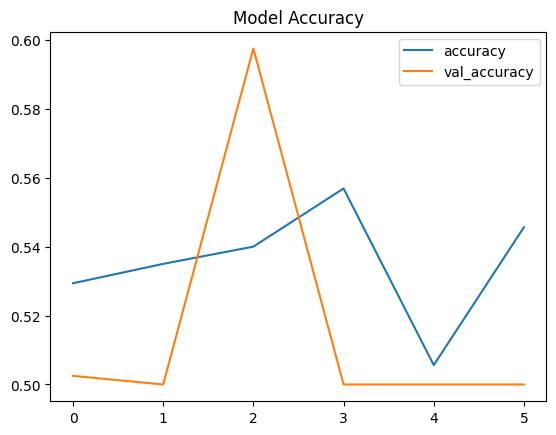

In [24]:
history_df = pd.DataFrame(history.history)
history_df[['accuracy','val_accuracy']].plot()
plt.title('Model Accuracy')
plt.show()

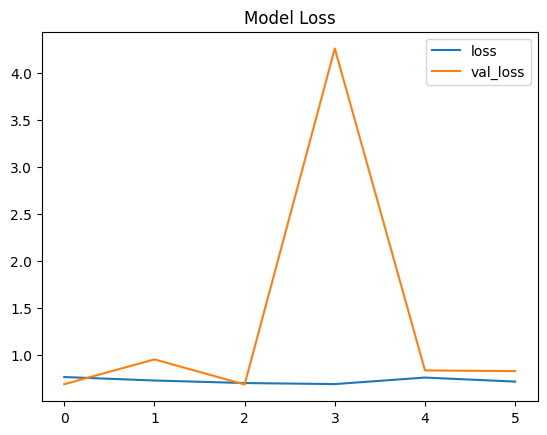

In [25]:
history_df[['loss','val_loss']].plot()
plt.title('Model Loss')
plt.show()

In [26]:
Y_pred = model.predict(X_val)
Y_pred = np.argmax(Y_pred, axis=1)

print(classification_report(Y_val, Y_pred, target_names=classes))

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step
                     precision    recall  f1-score   support

 Anemic_individuals       0.57      0.82      0.67       200
Healthy_individuals       0.68      0.37      0.48       200

           accuracy                           0.60       400
          macro avg       0.62      0.60      0.58       400
       weighted avg       0.62      0.60      0.58       400



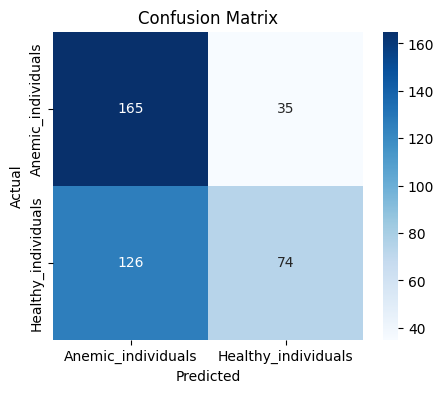

In [27]:
cm = confusion_matrix(Y_val, Y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()